# import

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

rc_fonts = {
    "font.family": "serif",
    "font.size": 20,
    'figure.figsize': (5, 3),
    "text.usetex": True
}
mpl.rcParams.update(rc_fonts)



In [14]:
# Set swimming speed and detect distance observed in experiment from Vissier: Small, wet & rational, 2011.
Points = ([int(500/70),int(250/30),int(140/19)])

In [15]:
PreyType = ['Loboea', 'Strobilidium', 'G. dominans'] # Scientific name of preys
PreySpeed = np.array([0.0005, 0.001,0.0006]) # Speed of preys
PreySize = np.array([65e-6,10e-6,19e-6]) # Size of preys
ExperimentalDetectionBodylenghts = Points 
nu  = 1e-6 # water viscosity

style = ['-', '--', '-.']
color = ['black', 'red', 'green']
KolSpeed = np.linspace(10e-4, 10e-3, 1000) # Kolmogorov speed
epsilon = np.round(np.log(KolSpeed**4/nu),2) # Kolmogorov kinetic energy 
TurbulenceFreq = np.linspace(10e2, 10e-2, 1000) # Kolmogorov turbulence frequency

# Calculate the detection distance
def Detectiondistance(Preyspeed, epsilon):
    return 3/2*(Preyspeed*np.sqrt(nu)/np.sqrt(epsilon))**(1/3)

def DetectiondistanceKol(Preyspeed, KolSpeed):
    return 3*(Preyspeed/KolSpeed)**(1/3)

def DetectiondistanceGrad(Preyspeed, Preysize, TurbulenceFreq):
    return (3*Preyspeed*TurbulenceFreq/(Preysize))**(1/3)

# Set copepods sensitivity treshold s^{-1}
SensitivityTreshold = 0.04


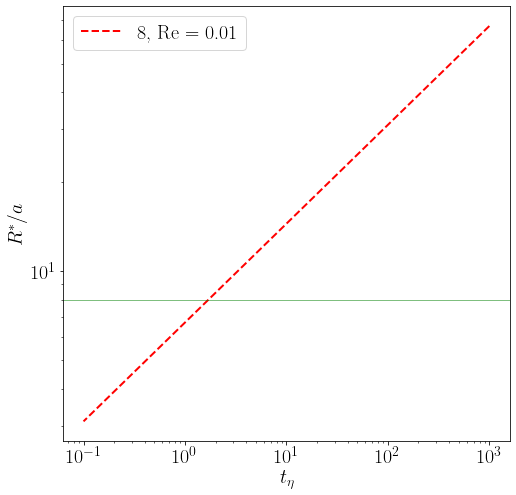

In [27]:

fig, ax = plt.subplots(figsize=(8,8))

i = 1   
Reynolds = np.round(PreySpeed[i]*PreySize[i]/nu, 3)

# Using kolmogorov velocity scale
ax.plot(TurbulenceFreq, DetectiondistanceGrad(PreySpeed[i], PreySize[i], TurbulenceFreq), style[i], color = color[i], linewidth=2.0, label=str(ExperimentalDetectionBodylenghts[i])+", $\mathrm{Re}$ = "+str(Reynolds))
plt.axhline(y=8, color = 'green', linestyle='-', linewidth= 0.5)

ax.set_xlabel("$t_{\eta}$") 
ax.set_ylabel("$R^*/a$")

plt.loglog()
plt.legend()

# New trial

In [28]:
a = 0.00003 # prey size
V0 = 0.001 # prey speed
s = 0.034 # copepods sensitivity treshold
tau_s = 350/40                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
MaxTau = a/(3*V0)
MinTau = tau_s
MaxDetectionDistance = (3*V0*tau_s/a)**(1/3)
KolSpeed = np.linspace(10e-4, 10e-2, 1000)

Epsilon = np.round(np.log(KolSpeed**4/nu),2)
def RadiusDetection(V0, a, tau):
    return (3*V0*tau/a)**(1/3)

Tau_Constant_Detection = np.linspace(10**2+1, MinTau, 1000)
Tau_Turbulence_Influence = np.linspace(MinTau, MaxTau, 1000)

# New trial with epsilon

In [30]:
nu = 1e-6

a = 0.00003
V0 = 0.001
s = 0.034
tau_s = 350/40

MaxTau = a/(3*V0)
MinTau = tau_s
MaxDetectionDistance = (3*V0*tau_s/a)**(1/3)

Tau_Constant_Detection = np.linspace(1e2, MinTau, 1000)
Tau_Turbulence_Influence = np.linspace(MinTau, MaxTau, 1000)

Epsilon_Constant_Detection = nu/Tau_Constant_Detection**2
Epsilon_Turbulence_Influence = nu/Tau_Turbulence_Influence**2

def RadiusDetection(V0, a, epsilon):
    tau = (nu/epsilon)**(1/2)
    return (3*V0*tau/a)**(1/3)


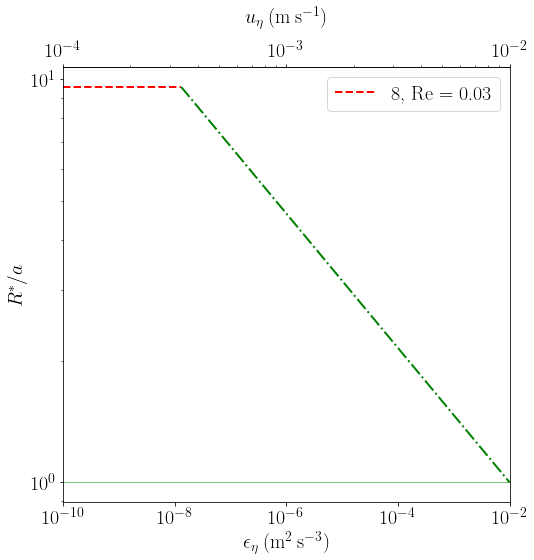

In [31]:
fig, ax = plt.subplots(figsize=(8,8))

i = 1   
Reynolds = np.round(a*V0/nu, 3)

ax.plot(Epsilon_Constant_Detection, np.ones(len(Epsilon_Constant_Detection))*MaxDetectionDistance, style[i], color = color[i], linewidth=2.0, label=str(ExperimentalDetectionBodylenghts[i])+", $\mathrm{Re}$ = "+str(Reynolds))
ax.plot(Epsilon_Turbulence_Influence, RadiusDetection(V0, a, Epsilon_Turbulence_Influence), style[2], color = color[2], linewidth=2.0)
plt.axhline(y=1, color = 'green', linestyle='-', linewidth= 0.5)

ax.set_xlabel("$\epsilon_{\eta}\: (\mathrm{m}^2\:\mathrm{s}^{-3})$") 
ax.set_ylabel("$R^*/a$")


def u_epsilon(epsilon):
    return (nu*epsilon)**(1/4)

def epsilon_u(u):
    return (u**4/nu)

secax = ax.secondary_xaxis('top', functions=(u_epsilon, epsilon_u))
secax.set_xlabel('$u_{\eta}\: (\mathrm{m}\:\mathrm{s}^{-1})$', labelpad = 20)

secax.set_xlim([10e-4, 10e-2])
ax.set_xlim([10e-11, 10e-3])
plt.loglog()
plt.legend()
#fig.savefig('Plot_Sensory_treshold.pdf', facecolor=fig.get_facecolor(), transparent=True)

<ipython-input-32-6c345a61b378>:11: RuntimeWarning: divide by zero encountered in true_divide
  return (nu/tau**2)
<ipython-input-32-6c345a61b378>:11: RuntimeWarning: divide by zero encountered in true_divide
  return (nu/tau**2)
<ipython-input-32-6c345a61b378>:11: RuntimeWarning: divide by zero encountered in true_divide
  return (nu/tau**2)


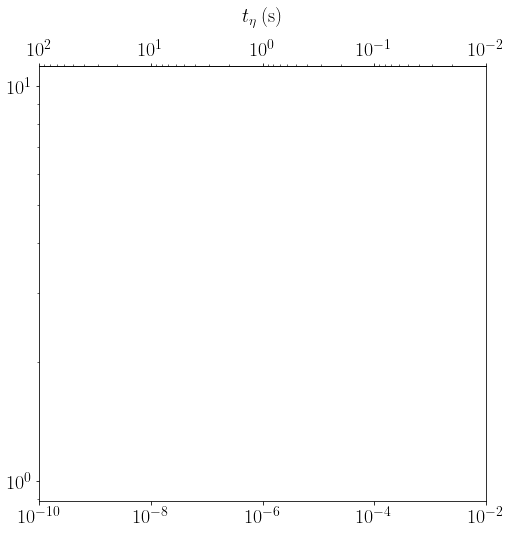

In [32]:
# Add plot for Kolmogorov time scale

fig, ax = plt.subplots(figsize=(8,8))

#ax.plot(Epsilon_Constant_Detection, np.ones(len(Epsilon_Constant_Detection))*MaxDetectionDistance, style[i], color = color[i], linewidth=2.0, label=str(ExperimentalDetectionBodylenghts[i])+", $\mathrm{Re}$ = "+str(Reynolds))
#ax.plot(Epsilon_Turbulence_Influence, RadiusDetection(V0, a, Epsilon_Turbulence_Influence), style[2], color = color[2], linewidth=2.0)


def tau_epsilon(epsilon):
    return (nu/epsilon)**(1/2)

def epsilon_tau(tau):
    return (nu/tau**2)

secax = ax.secondary_xaxis('top', functions=(tau_epsilon, epsilon_tau))
secax.set_xlabel('$t_{\eta}\: (\mathrm{s})$', labelpad = 20)

secax.set_xlim([1e2+1, 1e-2-1])
ax.set_yticks([])
ax.set_xlim([1e-10,1e-2])
plt.loglog()
plt.savefig('Time_For_treshold_2.pdf', transparent=True)

In [107]:
10e2

1000.0